In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import keras

In [4]:
from keras.models import Sequential #defines the connection style (sequential)

In [5]:
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization #introduces the types of layer we'll be needing

In [6]:
from keras.callbacks import ReduceLROnPlateau

In [7]:
dataset_path = "/content/drive/MyDrive/Building CNN model from scratch/"

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
import cv2
import os

In [12]:
import os
import cv2
import numpy as np

# ==========================================
# 1. GLOBAL CONFIGURATIONS
# ==========================================
# Defines our classification rules: 'normal' maps to 0, 'pneumonia' maps to 1
FOLDER_LABELS = ['NORMAL', 'PNEUMONIA']
IMAGE_TARGET_SIZE = 150

# **The dataset loading code**

In [13]:


# ==========================================
# 2. DATA PIPELINE FUNCTION
# ==========================================
#build_xray_dataset() (Action-oriented)

#image_ingestion_pipeline() (Very professional)
#The ETL (Extract, Transform, Load) Pipeline" (This is a highly respected industry term: you Extract from folders, Transform colors and shapes, and Load into a NumPy array)
def load_and_preprocess_images(target_directory):
    """
    Loops through the target subfolders, processes each image into a
    standardized grayscale matrix, and bundles it with its numeric label.
    """
    processed_dataset = []  # Master data collection basket

    for label_name in FOLDER_LABELS:
        # Stage 1: Dynamic path construction and class mapping
        folder_path = os.path.join(target_directory, label_name)
        class_index = FOLDER_LABELS.index(label_name)

        if not os.path.exists(folder_path):
            print(f"Warning: Directory not found -> {folder_path}")
            continue

        print(f"Loading files from: '{label_name}' (Assigned ID: {class_index})...")

        # Stage 2: Accessing and mass-processing individual files
        for image_name in os.listdir(folder_path):
            try:
                full_image_path = os.path.join(folder_path, image_name)

                # Transform: Read as Grayscale (1 channel) and resize to 150x150
                image_matrix = cv2.imread(full_image_path, cv2.IMREAD_GRAYSCALE)
                resized_matrix = cv2.resize(image_matrix, (IMAGE_TARGET_SIZE, IMAGE_TARGET_SIZE))

                # Synthesis: Bind the processed feature matrix to its label integer
                processed_dataset.append([resized_matrix, class_index])

            except Exception:
                # Defensive shield: Safely skip hidden files or corrupted images
                pass

    # Package everything cleanly into a high-performance NumPy array tensor
    return np.array(processed_dataset, dtype=object)

# ==========================================
# 3. PIPELINE EXECUTION
# ==========================================
# Your exact Google Drive directory path
train_path = '/content/drive/MyDrive/Building CNN model from scratch/ChestXRay2017/chest_xray/train'
test_path = '/content/drive/MyDrive/Building CNN model from scratch/ChestXRay2017/chest_xray/test'

print("--- PIPELINE START ---")
train_data = load_and_preprocess_images(train_path)
print(f"--- PIPELINE COMPLETE! Total loaded samples: {len(train_data)} ---")

test_data = load_and_preprocess_images(test_path)



--- PIPELINE START ---
Loading files from: 'NORMAL' (Assigned ID: 0)...
Loading files from: 'PNEUMONIA' (Assigned ID: 1)...
--- PIPELINE COMPLETE! Total loaded samples: 5232 ---
Loading files from: 'NORMAL' (Assigned ID: 0)...
Loading files from: 'PNEUMONIA' (Assigned ID: 1)...


In [14]:
print(f"--- PIPELINE COMPLETE! Total loaded samples: {len(test_data)} ---")

--- PIPELINE COMPLETE! Total loaded samples: 624 ---


as you can see 5232 samples of training data + 624 ssample for testing data

Once we preprocessed the dataset once, then we have to save it, and then simply load the processed arrays whenever we want to experiment with different CNN architectures or any other kind of experiments we want!

Since our dataset is already a NumPy array then we can store it into a .npy file which is very suitable/proper for this kind of datasets since this kind of file format is made to store a single multidimensional numeric array on disk ! (which is our case)

In [15]:
np.save('/content/drive/MyDrive/Building CNN model from scratch/train_data.npy', train_data)
np.save('/content/drive/MyDrive/Building CNN model from scratch/test_data.npy', test_data)

In [16]:
os.listdir('/content/drive/MyDrive/Building CNN model from scratch/')

['Building_CNN_model_from_scratch.ipynb',
 'ChestXRay2017',
 'train_data.npy',
 'test_data.npy',
 'X_train_normalized_reshaped.npy',
 'X_val_normalized_reshaped.npy',
 'X_test_normalized_reshaped.npy']

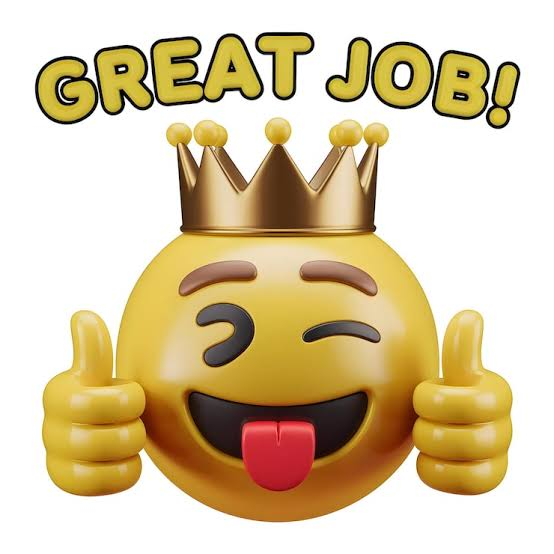

In [17]:
import numpy as np

train = np.load(
    '/content/drive/MyDrive/Building CNN model from scratch/train_data.npy',
    allow_pickle=True
)


test = np.load(
    '/content/drive/MyDrive/Building CNN model from scratch/test_data.npy',
    allow_pickle=True
)

# After Loading the datasets train & test

<Axes: xlabel='count'>

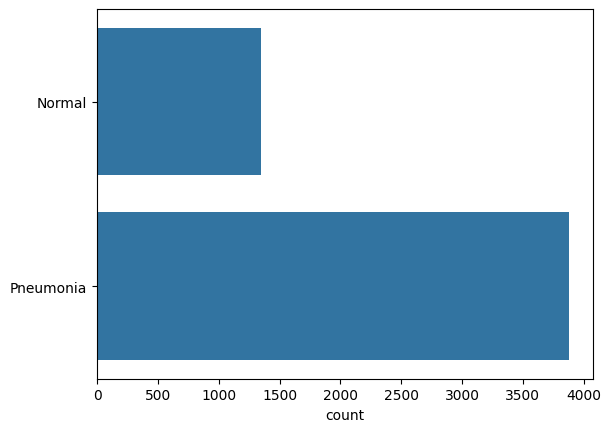

In [18]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
#sns.set_style('darkgrid')
sns.countplot(l)# by default the labels are placed within the horizontal axis y just like putting y= data labels

<Axes: ylabel='count'>

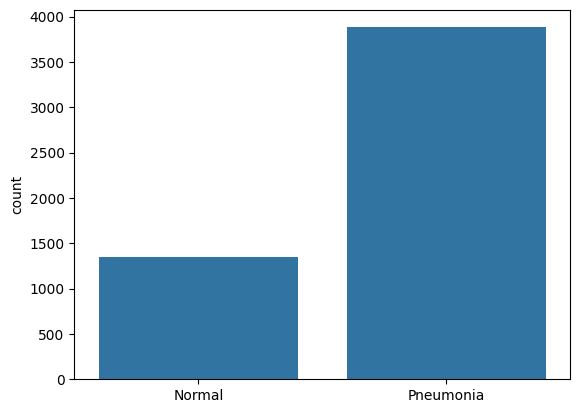

In [19]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
#sns.set_style('darkgrid')
sns.countplot(x=l)#If you want vertical bars then specify ==> x=the data to show/labels

/tmp/ipykernel_2513/2273886097.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=l, palette=["green", "red"])# use palette argument to change the bar colors into significant colors


<Axes: ylabel='count'>

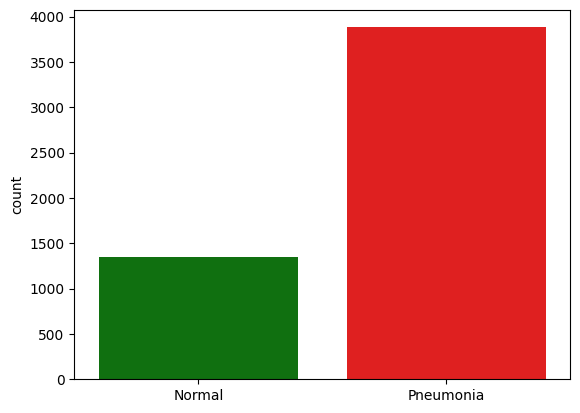

In [20]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
#sns.set_style('darkgrid')
sns.countplot(x=l, palette=["green", "red"])# use palette argument to change the bar colors into significant colors

/tmp/ipykernel_2513/1822809063.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=l, palette=["green", "red"])# use palette argument to change the bar colors into significant colors


Text(0.5, 1.0, 'checking dataset balance')

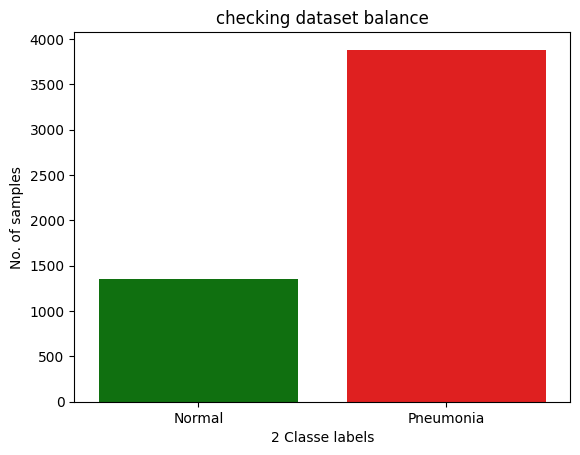

In [21]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
#sns.set_style('darkgrid')
sns.countplot(x=l, palette=["green", "red"])# use palette argument to change the bar colors into significant colors


######################################
#adding these 2 couple of lines for better plot inspection
######################################

plt.xlabel("2 Classe labels")
plt.ylabel("No. of samples")
plt.title("checking dataset balance")

the dataset is very imbalanced so we will be employ the augmentation technique


array([[136, 127, 165, ..., 198, 152, 141],
       [132, 126, 163, ..., 187, 159, 139],
       [123, 144, 154, ..., 183, 154, 134],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
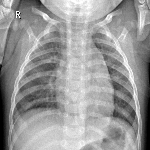

In [22]:
train[0][0] #since it is (150,150) then it's 2D image with only 1 channel

In [23]:
train[0][1]

0

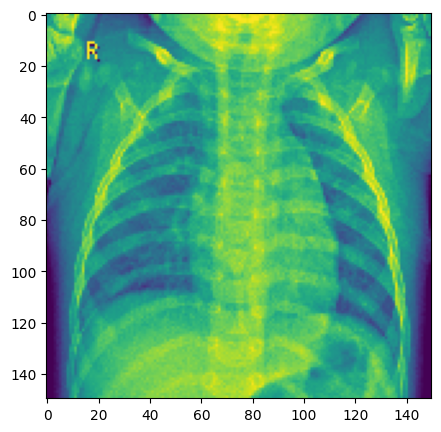

In [24]:
# 1. Setting our moderate figure canvas size
plt.figure(figsize = (5,5))

plt.imshow(train[0][0])

In [25]:
print(plt.get_cmap())#this is goona print out the memory address representation of the object (colormap)

In [26]:
print(plt.get_cmap().name)

viridis


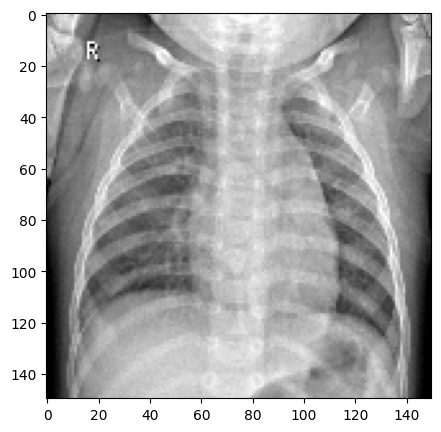

In [27]:
# 1. Setting our moderate figure canvas size
plt.figure(figsize = (5,5))

plt.imshow(train[0][0], cmap="gray")

Text(0.5, 1.0, 'Chest X-Rays NORMAL case')

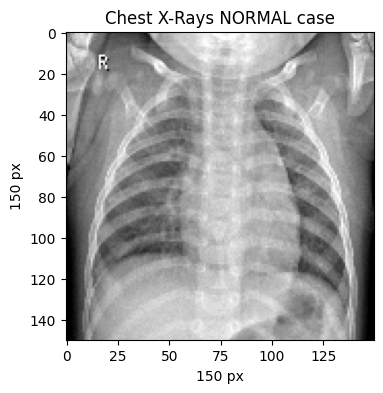

In [28]:
# 1. Setting our moderate figure canvas size
plt.figure(figsize = (4,4))

plt.imshow(train[0][0], cmap="gray")
plt.xlabel("150 px")
plt.ylabel("150 px")
plt.title(f"Chest X-Rays {FOLDER_LABELS[train[0][1]]} case")

Text(0.5, 1.0, 'Cest X-Rays 1 case')

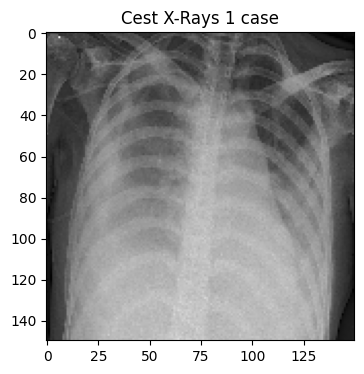

In [29]:
plt.figure(figsize=(4,4))
plt.imshow(train[-1][0], cmap=("gray"))
plt.title(f"Cest X-Rays {train[-1][1]} case")

In [30]:
#recall of the shape of our training dataset !
train.shape

#we have 5232 rows (5232 samples= 5,232 distinct patient)
# + 2 columns

#Column 0: A massive block of 150 * 150 = 22,500 integers (the image)
# & Column 1:  1 scalar value (an integer)

(5232, 2)

In [31]:
print(train.shape)

(5232, 2)


# **Data splitting**

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Carve them out (Phase 1 of your checklist)

X_all = np.array([item[0] for item in train])  # Pulls the (150, 150) images

Y_all = np.array([item[1] for item in train])  # Pulls the labels

# 2. Check your new shapes before splitting (Sanity check)
print(X_all.shape)  # Will output: (5232, 150, 150) -> Clean 3D Tensor!
print(Y_all.shape)  # Will output: (5232,)         -> Clean 1D Array!


(5232, 150, 150)
(5232,)


In [33]:
X_train, X_val, Y_train  , Y_val = train_test_split(
    X_all,
    Y_all,
    test_size=0.2,
    random_state=42,
    stratify=Y_all
)

In [34]:
# ( 5232*80 ) / 100 = 4 185,6 roughly 4185 samples from the raw training dataset (80% for training)
X_train.shape

(4185, 150, 150)

In [35]:
# (5232*20 ) /100 = 1 046,4 roughly 1047 samples from the raw training sataset ==> (20% for validation + hyperparameter tuning)
X_val.shape

(1047, 150, 150)

# Now if we really want to visually prove that stratify=Y_all preserved the class distribution

**One way of doing this :**

In [36]:
normal_count1 = 0
pneumonia_count1 = 0

for label in Y_all:
    if label == 0:
        normal_count1 += 1
    else:
        pneumonia_count1 += 1
print(f"{normal_count1} normal cases before  splitting")
print(f"{pneumonia_count1} pneumonia cases before splitting")


1349 normal cases before  splitting
3883 pneumonia cases before splitting


In [37]:
normal_count2 = 0
pneumonia_count2 = 0

for label in Y_train:
    if label == 0:
        normal_count2 += 1
    else:
        pneumonia_count2 += 1

print(f"{normal_count2} normal cases in training class after splitting")
print(f"{pneumonia_count2} pneumonia cases in training class after splitting")

1079 normal cases in training class after splitting
3106 pneumonia cases in training class after splitting


In [38]:
normal_count3 = 0
pneumonia_count3 = 0

for label in Y_val:
    if label == 0:
        normal_count3 += 1
    else:
        pneumonia_count3 += 1

print(f"{normal_count3} normal cases in validation class after splitting")
print(f"{pneumonia_count3} pneumonia cases in validation class after splitting")

270 normal cases in validation class after splitting
777 pneumonia cases in validation class after splitting


Now we only need to give those counts to plt.pie()

**==>The pie chart needs a list of values, so we need to put them together :**

In [39]:
counts1=[normal_count1,pneumonia_count1]
print(counts1)

[1349, 3883]


In [40]:
counts2=[normal_count2,pneumonia_count2]
counts3=[normal_count3, pneumonia_count3]
print(counts2, counts3)

[1079, 3106] [270, 777]


In [41]:
import matplotlib

print(matplotlib.__version__)

3.10.0


([<matplotlib.patches.Wedge at 0x7c5ff87bd400>,
 [Text(0.7967287443546388, 0.7584347749932625, 'NORMAL'),
  Text(-0.7967288106591122, -0.7584347053410179, 'PNEUMONIA')],
 [Text(0.43457931510253023, 0.4136916954508704, '25.8%'),
  Text(-0.43457935126860664, -0.413691657458737, '74.2%')])

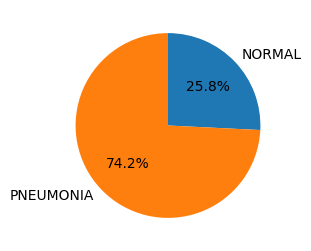

In [42]:
plt.figure(figsize=(3,3))
plt.pie(
    counts1,
    labels=["NORMAL", "PNEUMONIA"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock= False
)

Text(0.5, 1.0, 'The validation dataset classes distribution')

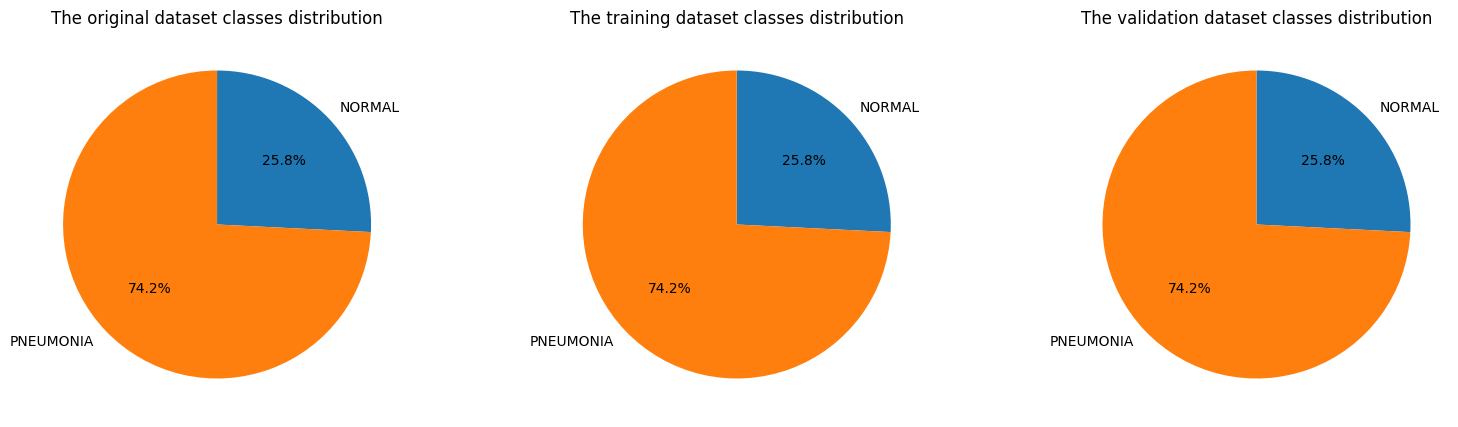

In [43]:
plt.figure(figsize=(19,5))

#Create a grid with 1 row and 3 columns, and use the first space !
plt.subplot(1, 3, 1)
plt.pie(counts1, labels=["NORMAL", "PNEUMONIA"], autopct="%1.1f%%", startangle=90, counterclock=False )
plt.title("The original dataset classes distribution")

#Create a grid with 1 row and 3 columns, and use the 2nd space !
plt.subplot(1,3,2)
plt.pie(counts2,labels=["NORMAL", "PNEUMONIA"], autopct="%1.1f%%", startangle=90, counterclock=False)
plt.title("The training dataset classes distribution")

#Create a grid with 1 row and 3 columns, and use the 3rd space !
plt.subplot(1,3,3)
plt.pie(counts3,labels=["NORMAL", "PNEUMONIA"], autopct="%1.1f%%", startangle=90, counterclock=False)
plt.title("The validation dataset classes distribution")

One another way of doing this in senior way

[1349 3883]
Text(0.5, 1.0, 'Original Dataset')
[1079 3106]
Text(0.5, 1.0, 'Training Set')
[270 777]
Text(0.5, 1.0, 'Validation Set')


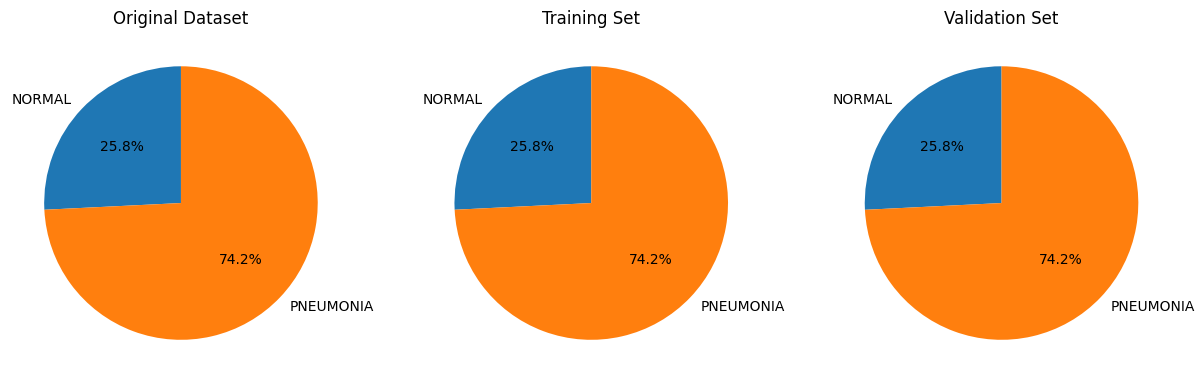

In [44]:
import matplotlib.pyplot as plt
import numpy as np

datasets = {
    "Original Dataset": Y_all,
    "Training Set": Y_train,
    "Validation Set": Y_val
}

labels = ["NORMAL", "PNEUMONIA"]

fig, plot_area = plt.subplots(1, 3, figsize=(15, 5)) # we're using the object-oriented mathplotlib style

#dataset.items ==> returns a 2 tuple (a pair of key value)
for plot_area, (key, value) in zip(plot_area, datasets.items()):

    # Count the occurrence of each
    counts = np.bincount(value)
    print(counts)

    plot_area.pie(
        counts,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90
    )

    plot_area.set_title(key) #method of the plot_area object
    print(plot_area.title) #Attribute of the plot_area object

plt.show()


# Dataset Normalization

In [45]:
print(X_train.dtype)

uint8


In [46]:
X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0

print(X_train_normalized)

[[[0.2        0.20392157 0.25098039 ... 0.18431373 0.16078431 0.16078431]
  [0.19607843 0.23529412 0.27843137 ... 0.20392157 0.18039216 0.15686275]
  [0.21568627 0.25098039 0.31372549 ... 0.23921569 0.18431373 0.16078431]
  ...
  [0.0745098  0.0745098  0.07058824 ... 0.07843137 0.0745098  0.0745098 ]
  [0.0745098  0.0745098  0.07058824 ... 0.07843137 0.0745098  0.0745098 ]
  [0.0745098  0.0745098  0.07058824 ... 0.0745098  0.0745098  0.07843137]]

 [[0.87843137 0.68627451 0.46666667 ... 0.63529412 0.61568627 0.56862745]
  [0.88235294 0.68627451 0.45490196 ... 0.65490196 0.85098039 0.58039216]
  [0.8745098  0.69803922 0.44313725 ... 0.90588235 0.6        0.50196078]
  ...
  [0.79215686 0.41568627 0.07843137 ... 1.         0.         0.03137255]
  [0.78823529 0.40392157 0.07843137 ... 0.01960784 0.00784314 0.01960784]
  [0.77254902 0.41568627 0.08235294 ... 0.01568627 0.01960784 0.01960784]]

 [[0.22745098 0.22352941 0.21176471 ... 0.33333333 0.31764706 0.3254902 ]
  [0.21960784 0.211764

In [47]:
print(X_train_normalized.min())
print(X_train_normalized.max())

0.0
1.0


**Now all our pixels are normalized since the min value is 0 and the max value is 1 as shown in the cell above**

In [48]:
X_test = []
Y_test= []

for image, label in test:
    X_test.append(image)
    Y_test.append(label)

X_test= np.array(X_test)
Y_test = np.array(Y_test)

In [49]:
X_test_normalized = X_test / 255.0
print(X_test)
print(X_test_normalized)

[[[ 25  24  21 ...  51  68 101]
  [ 25  20  20 ...  49  68  99]
  [ 22  23  22 ...  53  69  98]
  ...
  [ 19  20  18 ...  34  40  48]
  [ 16  20  19 ...  33  38  49]
  [ 18  19  18 ...  35  41  51]]

 [[  1   3   3 ...   8   6   3]
  [  1   2   3 ...   7   4   5]
  [  2   3   4 ...   7   4   3]
  ...
  [  0   1   1 ...   5   5   6]
  [  0   1   1 ...   3   4   5]
  [  0   1   1 ...   5   7   4]]

 [[  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 ...

 [[  0   1   1 ...  24   8   0]
  [  0   0   0 ...  34  11   0]
  [  0   0   0 ...  36  12   0]
  ...
  [  0   0   9 ...  22   2   3]
  [  0   0   8 ...  24   2   2]
  [  0   0  10 ...  22   2   2]]

 [[ 71  69  68 ...  34  38  35]
  [ 77  76  78 ...  31  30  56]
  [ 71  69  73 ...  39  25  46]
  ...
  [ 27  26  27 ...  40  43  47]
  [ 27  26  27 ...  40  43  47]
  [ 27  27  27 ...  40  42  

In [50]:
print(X_test.min())
print(X_test.max())

0
255


In [51]:
print(X_test_normalized.min())
print(X_test_normalized.max())

0.0
1.0


In [52]:
X_train_normalized.shape


(4185, 150, 150)

In [53]:
X_test_normalized.shape


(624, 150, 150)

In [54]:
X_train_normalized_reshaped= X_train_normalized.reshape(-1, IMAGE_TARGET_SIZE, IMAGE_TARGET_SIZE, 1)
X_val_normalized_reshaped= X_val_normalized.reshape(-1, IMAGE_TARGET_SIZE, IMAGE_TARGET_SIZE, 1)
X_test_normalized_reshaped= X_test_normalized.reshape(-1, IMAGE_TARGET_SIZE, IMAGE_TARGET_SIZE, 1)

In [55]:
X_train_normalized_reshaped.shape

(4185, 150, 150, 1)

In [56]:
X_val_normalized_reshaped.shape

(1047, 150, 150, 1)

In [57]:
X_test_normalized_reshaped.shape

(624, 150, 150, 1)

# Now that our data is perfectly Extracted, Transformed, and Loaded into train_data & test_data (ETL tasks are thoroughly successful), **`the data engineering phase is complete`**.

In [58]:
np.save("/content/drive/MyDrive/Building CNN model from scratch/X_train_normalized_reshaped.npy",X_train_normalized_reshaped)
np.save("/content/drive/MyDrive/Building CNN model from scratch/X_val_normalized_reshaped.npy",X_val_normalized_reshaped)
np.save("/content/drive/MyDrive/Building CNN model from scratch/X_test_normalized_reshaped.npy",X_test_normalized_reshaped)

In [59]:
os.listdir("/content/drive/MyDrive/Building CNN model from scratch")

['Building_CNN_model_from_scratch.ipynb',
 'ChestXRay2017',
 'train_data.npy',
 'test_data.npy',
 'X_train_normalized_reshaped.npy',
 'X_val_normalized_reshaped.npy',
 'X_test_normalized_reshaped.npy']

In [60]:
train_set=np.load('/content/drive/MyDrive/Building CNN model from scratch/X_train_normalized_reshaped.npy')
val_set=np.load('/content/drive/MyDrive/Building CNN model from scratch/X_val_normalized_reshaped.npy')
test_set=np.load('/content/drive/MyDrive/Building CNN model from scratch/X_test_normalized_reshaped.npy')

In [61]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)

datagen.fit(train_set)

# **CNNs layers Design settings**


In [62]:
model = Sequential()

#1st Block
convLayer1= Conv2D(
    filters=32,
    kernel_size=(3,3) ,
    strides = 1 ,
    padding = 'same' ,
    activation = 'relu' ,
    input_shape = (150,150,1)
)

#1st CNN layer def:
model.add( convLayer1 )


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
#Now let's include the batchNormalization layer
batchNormLayer1= BatchNormalization()
#2nd layer def :
model.add(batchNormLayer1)

In [64]:
maxPoolLayer1= MaxPool2D(
    pool_size=(2,2) ,
    strides = 2 ,
    padding = 'same'
)
#3rd CNN layer def:
model.add(  maxPoolLayer1  )


In [65]:
#2nd Block

convLayer2= Conv2D(
    filters=64,
    kernel_size=(3,3) ,
    strides = 1 ,
    padding = 'same' ,
    activation = 'relu' ,
)

#4th CNN layer def:
model.add( convLayer2 )

#Let's discard some conv activations
dropoutLayer1= Dropout(
    rate=0.1
    )

#5th CNN layer def
model.add( dropoutLayer1 )


#let's normalize/ stabilize the rest of conv activations
batchNormLayer2= BatchNormalization()

#6th CNN layer def :
model.add(batchNormLayer2)


maxPoolLayer2= MaxPool2D(
    pool_size=(2,2) ,
    strides = 2 ,
    padding = 'same'
)
#6th CNN layer def:
model.add(  maxPoolLayer2  )


In [66]:
#3rd Block

#7th layer
convLayer3= Conv2D(
        filters= 64 ,
        kernel_size=(3,3) ,
        strides = 1 ,
        padding = 'same' ,
        activation = 'relu'
        )


model.add( convLayer3 )


#let's normalize/ stabilize the rest of conv activations
batchNormLayer3= BatchNormalization()

#8th CNN layer def :
model.add(batchNormLayer3)


maxPoolLayer3= MaxPool2D(
    pool_size=(2,2) ,
    strides = 2 ,
    padding = 'same'
)
#9th CNN layer def:
model.add(  maxPoolLayer3  )


In [67]:
#4th Block

#10th layer
convLayer4= Conv2D(
        filters= 128 ,
        kernel_size= (3,3) ,
        strides = 1 ,
        padding = 'same' ,
        activation = 'relu'
        )


model.add( convLayer4 )

######################################
dropoutLayer2= Dropout(
    rate=0.2
    )

#11th CNN layer def
model.add( dropoutLayer2 )
######################################

#12th layer
batchNormLayer4= BatchNormalization()
model.add(batchNormLayer4)
######################################

maxPoolLayer4= MaxPool2D(
    pool_size=(2,2) ,
    strides = 2 ,
    padding = 'same'
)
#13th CNN layer def:
model.add(  maxPoolLayer4  )

######################################




In [68]:
#5th Block

#14th layer
convLayer5= Conv2D(
        filters= 256 ,
        kernel_size= (3,3) ,
        strides = 1 ,
        padding = 'same' ,
        activation = 'relu'
        )


model.add( convLayer5 )

######################################
dropoutLayer3= Dropout(
    rate=0.2
    )

#15th CNN layer def
model.add( dropoutLayer3 )
######################################

#16th layer
batchNormLayer5= BatchNormalization()
model.add(batchNormLayer5)
######################################

maxPoolLayer5= MaxPool2D(
    pool_size=(2,2) ,
    strides = 2 ,
    padding = 'same'
)
#17th CNN layer def:
model.add(  maxPoolLayer5  )

######################################




In [69]:
#18th CNN layer def:
flatten_layer = Flatten()
model.add(flatten_layer)

In [70]:
#17th CNN layer def:
denseLayer= Dense(
    units = 128 ,
    activation = 'relu'
    )

model.add(denseLayer)


In [71]:
######################################
dropoutLayer4= Dropout(
    rate=0.2
    )

#18th CNN layer def
model.add( dropoutLayer4 )
######################################


In [72]:
#19th CNN layer def:
denseLayer= Dense(
    units = 1,
    activation = 'sigmoid'
    )

model.add(denseLayer)


# **Training settings :**

In [73]:
model.compile(optimizer = "adam" , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [75]:
#learning-rate scheduling
LR_scheduling = ReduceLROnPlateau(
    monitor="val_accuracy",
    patience=5,
    #we're telling keras here to be be verbose whenever it makes any changes
    verbose=1,
    factor=0.3,
    min_lr=0.000001
)

In [76]:
# Training
history = model.fit(
    datagen.flow(
        X_train_normalized_reshaped,
        Y_train,
        batch_size=32
    ),
    epochs=12,
    validation_data=datagen.flow(
        X_val_normalized_reshaped,
        Y_val,
        batch_size=32
    ),
    callbacks=[LR_scheduling]
)


Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 0.8521 - loss: 0.4286 - val_accuracy: 0.7421 - val_loss: 8.1519 - learning_rate: 0.0010
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 356s 3s/step - accuracy: 0.9164 - loss: 0.2113 - val_accuracy: 0.7421 - val_loss: 6.1649 - learning_rate: 0.0010
Epoch 3/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.9245 - loss: 0.2130 - val_accuracy: 0.7421 - val_loss: 4.9352 - learning_rate: 0.0010
Epoch 4/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 0.9319 - loss: 0.1839 - val_accuracy: 0.7421 - val_loss: 5.6203 - learning_rate: 0.0010
Epoch 5/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.9355 - loss: 0.1743 - val_accuracy: 0.9160 - val_loss: 0.2631 - learning_rate: 0.0010
Epoch 6/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.9446 - loss: 0.1512 - val_accuracy: 0.7536 - val_loss: 1.7846 - learning_rate: 0.0010
Epoch 7/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 361s 3s/step - accuracy: 0.9434 - loss: 0.

In [77]:
# Testing
test_loss, test_accuracy = model.evaluate(
    X_test_normalized_reshaped,
    Y_test
)

print("Loss of the model is -", test_loss)
print("Accuracy of the model is -", test_accuracy * 100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 400ms/step - accuracy: 0.7837 - loss: 0.4397
Loss of the model is - 0.43967506289482117
Accuracy of the model is - 78.36538553237915 %


In [78]:
model.save(
    "/content/drive/MyDrive/Building CNN model from scratch/pneumonia_detection_model.keras"
)

# **Analysis after training**

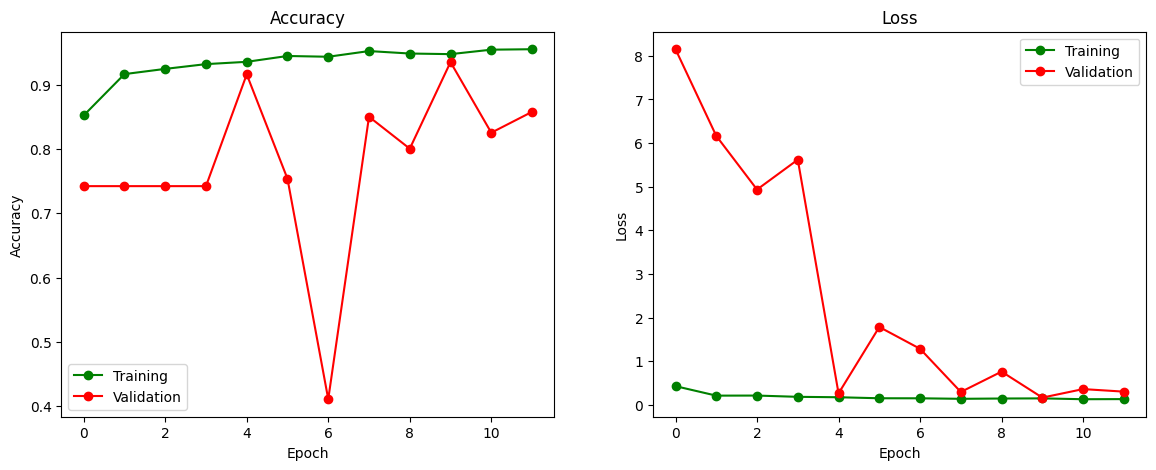

In [84]:
epochs = range(len(history.history['accuracy']))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax[0].plot(epochs, history.history['accuracy'], 'go-', label='Training')
ax[0].plot(epochs, history.history['val_accuracy'], 'ro-', label='Validation')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss
ax[1].plot(epochs, history.history['loss'], 'go-', label='Training')
ax[1].plot(epochs, history.history['val_loss'], 'ro-', label='Validation')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()


In [89]:
predictions = model.predict(X_test_normalized_reshaped)

predictions = (predictions > 0.5).astype(int).flatten()

print(predictions[:10])

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 514ms/step
[0 0 0 0 1 0 0 0 0 0]


In [90]:
from sklearn.metrics import classification_report

print(
    classification_report(
        Y_test,
        predictions,
        target_names=['Normal (Class 0)', 'Pneumonia (Class 1)']
    )
)

                     precision    recall  f1-score   support

   Normal (Class 0)       0.65      0.91      0.76       234
Pneumonia (Class 1)       0.93      0.71      0.80       390

           accuracy                           0.78       624
          macro avg       0.79      0.81      0.78       624
       weighted avg       0.82      0.78      0.79       624



In [91]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, predictions)
cm

array([[212,  22],
       [113, 277]])

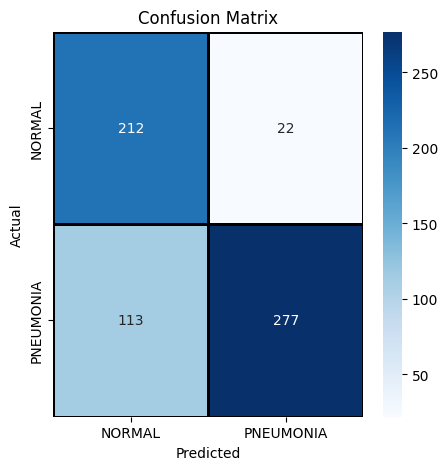

In [92]:
#we need first to turn the confusion matrix into a Pandas DataFrame
cm = pd.DataFrame(
    cm,
    index=['0', '1'],
    columns=['0', '1']
)

#now let's draw our heatmap
plt.figure(figsize=(5, 5))

sns.heatmap(
    cm,
    cmap="Blues",
    linecolor="black",
    linewidth=1,
    annot=True,
    fmt='',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
